In [1]:
import tensorflow as tf
from tensorflow import keras


tf.__version__

2026-01-29 10:15:29.525221: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-29 10:15:30.763859: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-29 10:15:34.008044: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


'2.20.0'

In [2]:
keras.__version__

'3.13.1'

In [3]:
# Load the fashion mnist dataset
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

print("Shape:" ,X_train_full.shape)
print("Data type:", X_train_full.dtype)

Shape: (60000, 28, 28)
Data type: uint8


In [4]:
# split the full training set into a validation set and a (smaller) training set. We also scale the pixel intensities down to the 0-1 range and convert them to floats, by dividing by 255.

X_valid, X_train, = X_train_full[:5000]/255.0 , X_train_full[5000:]/ 255.0
y_valid, y_train =  y_train_full[:5000], y_train_full[5000:]

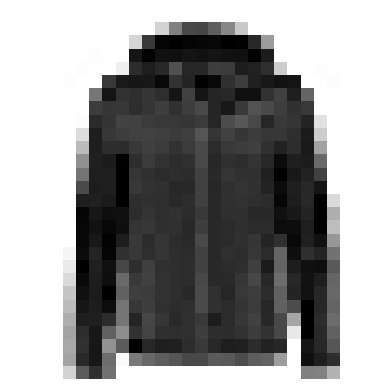

In [5]:
# Plot an image
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap="binary")
plt.axis("off")
plt.show()


In [6]:
# List of class names
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat","Sandal", "Shirt","Sneaker", "Bag", "Ankle Boot"]

# first image in the training set is
class_names[y_train[0]]

'Coat'

In [7]:
print("Shape of Validation Set:", X_valid.shape)
print("Shape of Test Set: ", X_test.shape)

Shape of Validation Set: (5000, 28, 28)
Shape of Test Set:  (10000, 28, 28)


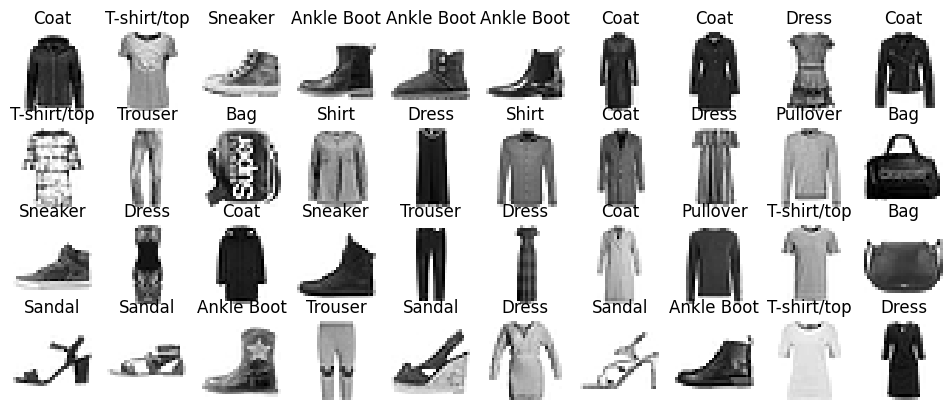

In [8]:
# A sample of images in the dataset
n_rows = 4
n_cols = 10

plt.figure(figsize=(n_cols * 1.2 , n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows,n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation='nearest')
        plt.axis("off")
        plt.title(class_names[y_train[index]], fontsize=12)
        
plt.subplots_adjust(wspace=0.2, hspace=0.2)
plt.show()

In [12]:
# Creating the model using the Sequencial api
model = keras.models.Sequential([
    keras.layers.Input(shape=[28,28]),
    keras.layers.Flatten(),
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

In [13]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Plotting the model
keras.utils.plot_model(model, "my_fashion_mnist_model.png", show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [18]:
# List of model layers
model.layers

[<Flatten name=flatten_2, built=True>,
 <Dense name=dense_6, built=True>,
 <Dense name=dense_7, built=True>,
 <Dense name=dense_8, built=True>]

In [19]:
hidden1 =model.layers[1]
hidden1.name

'dense_6'

In [21]:
#Check is  a layer is hidden
model.get_layer("dense_6") is hidden1

True

In [22]:
# All the parameters of a model can be accessed using its get_weights() and set_weights() methods. For a Dense layer this includes both the connection weights and the bias terms.

weights, biases =hidden1.get_weights()

In [23]:
weights

array([[-0.01657707, -0.06550526, -0.0638131 , ...,  0.0236229 ,
        -0.04025982, -0.01227956],
       [ 0.01761438,  0.01214483,  0.01256612, ..., -0.05885945,
         0.04980651,  0.04894859],
       [-0.03254399, -0.04843509,  0.06837614, ..., -0.03479401,
        -0.03926994, -0.04241665],
       ...,
       [-0.00674677,  0.05421366,  0.05824395, ...,  0.00648411,
         0.07064824, -0.01510284],
       [-0.05208788, -0.06064053, -0.06504855, ...,  0.00137375,
        -0.06587837,  0.06702001],
       [ 0.0278016 ,  0.03705195,  0.0491548 , ..., -0.06343743,
         0.03407793,  0.00668234]], shape=(784, 300), dtype=float32)

In [24]:
weights.shape

(784, 300)

In [25]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [26]:
biases.shape

(300,)

In [27]:
    # Compiling the model to sepcify its loss function, and the optimizer to use.
    
model.compile(loss="sparse_categorical_crossentropy",
            optimizer='sgd',
            metrics=['accuracy']
            )

In [28]:
# Training the model
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))

2026-01-29 12:26:12.959474: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 172480000 exceeds 10% of free system memory.


Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.7613 - loss: 0.7304 - val_accuracy: 0.8334 - val_loss: 0.5043
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.8303 - loss: 0.4884 - val_accuracy: 0.8434 - val_loss: 0.4560
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.8440 - loss: 0.4418 - val_accuracy: 0.8598 - val_loss: 0.4069
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.8545 - loss: 0.4137 - val_accuracy: 0.8672 - val_loss: 0.3939
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.8625 - loss: 0.3933 - val_accuracy: 0.8632 - val_loss: 0.3869
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.8655 - loss: 0.3803 - val_accuracy: 0.8712 - val_loss: 0.3729
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.8710 - loss: 0.3662 - val_accuracy: 0.8760 - val_loss: 0.3656
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 23s 14ms/step - accuracy: 0.8751 -

In [29]:
# Evaluating the model on the test set
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8268 - loss: 82.1115


[82.11151885986328, 0.8267999887466431]

In [ ]:
X_new= X_test[:3]
y_proba =model.predict(X_new)
y_proba.round(2)


# for each instance the model estimates one probability per class, from
#  class 0 to class 9. For example, for the first image it estimates that the probability of
#  class 9 (ankle boot) is 100%

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [35]:
# To get only the classes with the highest estimated probability
import numpy as np 

y_pred = np.argmax(model.predict(X_new), axis=-1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


array([9, 2, 1])

In [36]:
np.array(class_names)[y_pred]

array(['Ankle Boot', 'Pullover', 'Trouser'], dtype='<U11')

In [37]:
# verify whether the prediction is accurate

y_new = y_test[:3]
y_new

array([9, 2, 1], dtype=uint8)

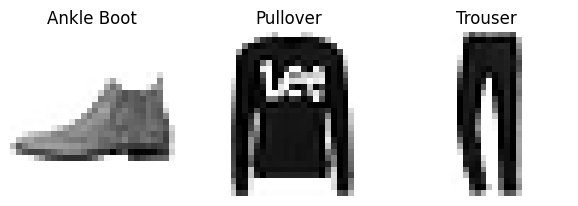

In [39]:
# Plot the predictions
plt.figure(figsize=(7.2, 2.4))

for index , image in enumerate(X_new):
    plt.subplot(1,3, index +1)
    plt.imshow(image, cmap="binary", interpolation="nearest")
    plt.axis('off')
    plt.title(class_names[y_test[index]], fontsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()